# ScorePredictor — Preprocessing Walkthrough (Colab-style)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hhenrichaguilar07-glitch/ScorePredictor/blob/main/ml_model/preprocessing_walkthrough.ipynb)

This notebook runs the **exact same pipeline** as `train_model.py`, but one step per
cell so you can *see* every stage:

1. Generate a **raw, messy** dataset (missing values, duplicates, outliers)
2. Inspect the raw data
3. Find & handle **missing values** (`SimpleImputer`, mean strategy)
4. Find & remove **duplicate rows**
5. Find & remove **outliers**
6. **Scale** the features (StandardScaler)
7. Train / test split
8. Train the model & evaluate (R²)

**▶ Run it in Google Colab (no setup needed):**

1. Click the **Open in Colab** badge above (or go to *File → Upload notebook* and drop in this `.ipynb`).
2. Choose **Runtime → Run all** (or press each cell's ▶ button top-to-bottom).
3. Everything is self-contained — the data is generated in the notebook, so there are **no files to upload**. Colab already has numpy, pandas, scikit-learn, and matplotlib installed, so the charts render too.

> The badge opens this notebook straight from GitHub, so push your latest commit to `main` first for it to reflect these steps.

In [2]:
import numpy as np
import pandas as pd
# matplotlib is optional (Colab has it built in). If it's missing locally, run
# `pip install matplotlib` -- but every DATA step still works without charts.
try:
    import matplotlib.pyplot as plt
    HAS_PLT = True
except ModuleNotFoundError:
    HAS_PLT = False
    print('matplotlib not installed -> charts will be skipped (data steps still run).')
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

# Same fixed seed as train_model.py -> identical numbers (655 raw -> 635 cleaned).
RNG = np.random.default_rng(42)
N_STUDENTS = 640
pd.set_option('display.max_columns', None)

## Step 1 — Generate the RAW (messy) dataset

Real student records are private, so we synthesize data and **deliberately inject**
the same problems real data collection produces: blank cells, duplicate rows, and
data-entry typos (e.g. `250` study hours instead of `25.0`).

In [3]:
def generate_raw_dataset(n=N_STUDENTS):
    study_hours = np.clip(RNG.normal(14.2, 5.0, n), 2, 30)
    attendance = np.clip(RNG.normal(81, 10, n), 50, 100)
    noise = RNG.normal(0, 3.4, n)
    exam_score = np.clip(11 + 2.1 * study_hours + 0.45 * attendance + noise, 0, 100)
    df = pd.DataFrame({
        'study_hours': np.round(study_hours, 1),
        'attendance': np.round(attendance, 1),
        'exam_score': np.round(exam_score, 1),
    })
    # Inject MISSING VALUES (~3% blank cells in two columns)
    n_missing = int(0.03 * n)
    df.loc[RNG.choice(df.index, n_missing, replace=False), 'study_hours'] = np.nan
    df.loc[RNG.choice(df.index, n_missing, replace=False), 'attendance'] = np.nan
    # Inject DUPLICATE ROWS (same record entered twice)
    df = pd.concat([df, df.sample(n=15, random_state=1)], ignore_index=True)
    # Inject OUTLIERS (impossible study hours = typos)
    df.loc[RNG.choice(df.index, 5, replace=False), 'study_hours'] = [250.0, 300.0, 180.0, 220.0, 275.0]
    # Shuffle so the problems are spread throughout
    return df.sample(frac=1, random_state=7).reset_index(drop=True)

raw = generate_raw_dataset()
print('Raw shape (rows, columns):', raw.shape)
raw.head(10)

Raw shape (rows, columns): (655, 3)


,study_hours,attendance,exam_score
0,12.1,73.1,63.0
1,18.2,70.3,79.3
2,3.9,82.3,59.0
3,11.8,99.8,78.6
4,13.7,86.6,76.8
5,21.5,77.2,83.2
6,15.8,88.2,86.9
7,11.9,88.0,73.0
8,11.3,71.0,71.5
9,11.5,79.8,67.2


## Step 2 — Inspect the raw data

`describe()` already hints at problems: look at the **max** of `study_hours` (it should
be ~30 but shows 300 — outliers) and the **count** row (less than the total — missing values).

In [4]:
raw.describe().round(2)

,study_hours,attendance,exam_score
count,634.00,636.00,655.00
mean,15.89,80.84,76.47
std,21.35,9.79,11.25
min,2.00,50.00,46.50
25%,10.70,74.28,68.90
50%,14.25,81.10,76.70
75%,17.18,87.32,83.90
max,300.00,100.00,100.00


In [5]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 655 entries, 0 to 654
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  634 non-null    float64
 1   attendance   636 non-null    float64
 2   exam_score   655 non-null    float64
dtypes: float64(3)
memory usage: 15.5 KB


## Step 3a — Find the MISSING values

`isnull().sum()` counts blanks per column. Then we look at a few actual rows that
contain a blank (shown as `NaN`).

In [6]:
print('Missing values per column:')
print(raw.isnull().sum())
print('\nTotal missing cells:', int(raw.isnull().sum().sum()))

Missing values per column:
study_hours    21
attendance     19
exam_score      0
dtype: int64

Total missing cells: 40


In [7]:
# Show some rows that actually have a missing value
raw[raw.isnull().any(axis=1)].head(10)

,study_hours,attendance,exam_score
19,20.9,NaN,89.3
20,NaN,86.6,81.0
32,NaN,80.1,76.5
47,NaN,93.3,87.6
56,NaN,90.2,68.4
79,10.1,NaN,70.9
88,NaN,88.9,91.0
95,NaN,58.2,57.3
113,11.1,NaN,68.3
164,NaN,84.7,96.6


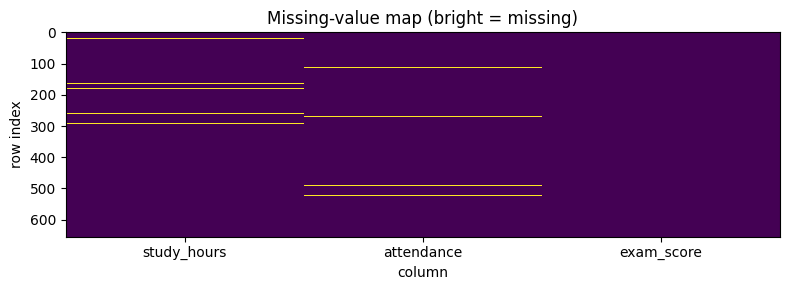

In [8]:
# Visualize where the missing cells are (bright streaks = missing)
if HAS_PLT:
    plt.figure(figsize=(8, 3))
    plt.imshow(raw.isnull(), aspect='auto', cmap='viridis', interpolation='nearest')
    plt.xticks(range(len(raw.columns)), raw.columns)
    plt.title('Missing-value map (bright = missing)')
    plt.xlabel('column'); plt.ylabel('row index')
    plt.tight_layout(); plt.show()
else:
    print('(chart skipped - matplotlib not installed)')

### Handle missing values — mean imputation with `SimpleImputer`

We use scikit-learn's **`SimpleImputer(strategy='mean')`** — the same tool `train_model.py`
uses — to fill each blank with that column's **mean** (a simple, common strategy). After
this, the missing count is **0**.

In [9]:
df = raw.copy()
# Mean imputation with scikit-learn's SimpleImputer -- the same tool (and
# strategy) train_model.py uses, so the notebook mirrors the script exactly.
num_cols = ['study_hours', 'attendance', 'exam_score']
imputer = SimpleImputer(strategy='mean')
df[num_cols] = imputer.fit_transform(df[num_cols])
df[num_cols] = df[num_cols].round(1)  # round back to 1 decimal so data stays tidy
print('Missing values AFTER imputation:', int(df.isnull().sum().sum()))

Missing values AFTER imputation: 0


## Step 3b — Find & remove DUPLICATE rows

`duplicated()` flags rows that are exact copies of an earlier row.

In [10]:
print('Duplicate rows found:', int(df.duplicated().sum()))
# Show a few duplicated rows (keep=False shows both the original and the copy)
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(10)

Duplicate rows found: 15


,study_hours,attendance,exam_score
73,8.6,86.3,70.6
101,8.6,86.3,70.6
97,8.6,97.2,76.4
221,8.6,97.2,76.4
143,12.0,72.4,62.2
415,12.0,72.4,62.2
279,12.1,72.6,69.3
332,12.1,72.6,69.3
115,13.7,81.8,71.1
323,13.7,81.8,71.1


In [11]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Removed {before - len(df)} duplicate row(s). Rows now: {len(df)}')

Removed 15 duplicate row(s). Rows now: 640


## Step 3c — Find & remove OUTLIERS

Valid weekly study hours are ~0–40. Anything above that is a data-entry error
(e.g. `250` meant `25.0`). The boxplot makes the outliers obvious.

In [12]:
# The impossible values
df[df['study_hours'] > 40]

,study_hours,attendance,exam_score
23,220.0,82.0,81.7
294,180.0,93.9,91.4
320,250.0,84.4,85.6
376,300.0,80.4,79.7
506,275.0,77.4,67.8


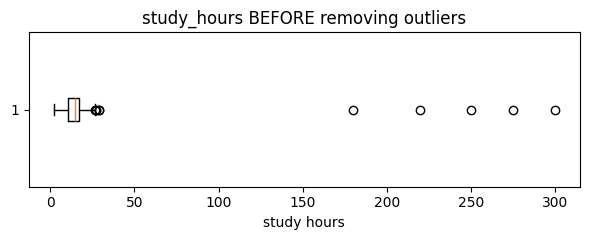

In [13]:
if HAS_PLT:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(df['study_hours'], vert=False)
    plt.title('study_hours BEFORE removing outliers')
    plt.xlabel('study hours'); plt.tight_layout(); plt.show()
else:
    print('(boxplot skipped - matplotlib not installed)')

Removed 5 outlier row(s). Clean rows: 635


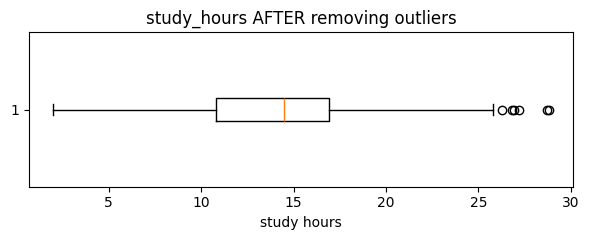

In [14]:
before = len(df)
df = df[(df['study_hours'] >= 0) & (df['study_hours'] <= 40)].reset_index(drop=True)
print(f'Removed {before - len(df)} outlier row(s). Clean rows: {len(df)}')

if HAS_PLT:
    plt.figure(figsize=(6, 2.5))
    plt.boxplot(df['study_hours'], vert=False)
    plt.title('study_hours AFTER removing outliers')
    plt.xlabel('study hours'); plt.tight_layout(); plt.show()
else:
    print('(boxplot skipped - matplotlib not installed)')

## Step 4 — Feature scaling (StandardScaler)

`study_hours` (~2–30) and `attendance` (~50–100) live on different scales. StandardScaler
rescales each to **mean 0, std 1** so neither feature dominates. Compare the `mean`/`std`
rows before vs after.

In [15]:
X = df[['study_hours', 'attendance']]
y = df['exam_score']

print('BEFORE scaling:')
print(X.describe().round(2).loc[['mean', 'std', 'min', 'max']])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('\nAFTER scaling (mean ~0, std ~1):')
print(X_scaled_df.describe().round(2).loc[['mean', 'std', 'min', 'max']])

BEFORE scaling:
      study_hours  attendance
mean        14.10       80.83
std          4.83        9.62
min          2.00       50.00
max         28.80      100.00

AFTER scaling (mean ~0, std ~1):
      study_hours  attendance
mean        -0.00        0.00
std          1.00        1.00
min         -2.50       -3.21
max          3.04        1.99


## Step 5 — Train / test split (80 / 20)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape[0]} rows (80%)')
print(f'Testing set : {X_test.shape[0]} rows (20%)')

Training set: 508 rows (80%)
Testing set : 127 rows (20%)


## Step 6 — Train the model & Step 7 — Evaluate

R² ≈ **0.89** means the model explains ~89% of the variation in exam scores.

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Coefficients (scaled): study_hours={model.coef_[0]:.3f}, attendance={model.coef_[1]:.3f}')
print(f'Intercept            : {model.intercept_:.3f}')
print(f'R-squared            : {r2:.3f}  (~{r2*100:.0f}% of variance explained)')
print(f'MAE                  : {mae:.2f} points')

Coefficients (scaled): study_hours=10.015, attendance=4.239
Intercept            : 76.484
R-squared            : 0.889  (~89% of variance explained)
MAE                  : 2.73 points


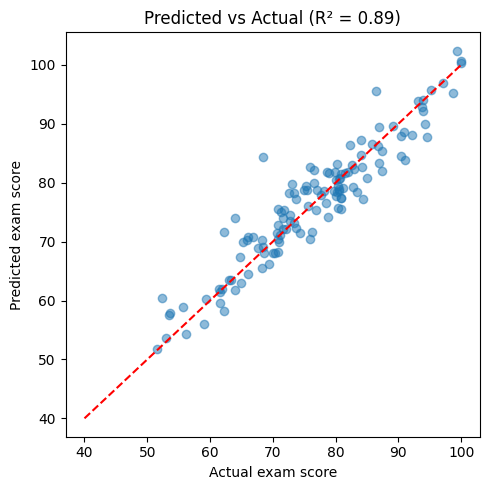

In [18]:
# Predicted vs actual — points near the diagonal = good predictions
if HAS_PLT:
    plt.figure(figsize=(5, 5))
    plt.scatter(y_test, y_pred, alpha=0.5)
    lims = [40, 100]
    plt.plot(lims, lims, 'r--')
    plt.xlabel('Actual exam score'); plt.ylabel('Predicted exam score')
    plt.title(f'Predicted vs Actual (R² = {r2:.2f})')
    plt.tight_layout(); plt.show()
else:
    print('(scatter plot skipped - matplotlib not installed)')

## (Optional) Step 8 — Save the artifacts

Uncomment to write `model.pkl`, `scaler.pkl`, and the cleaned CSV — exactly what
`train_model.py` produces for the Flask backend. In **Colab** these land in the
temporary session storage, so the last lines use `google.colab.files.download(...)`
to pull them to your computer (that part is skipped automatically when you run
outside Colab).

In [ ]:
# import pickle
# with open('model.pkl', 'wb') as f: pickle.dump(model, f)
# with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
# df.to_csv('student_data.csv', index=False)
# print('Saved model.pkl, scaler.pkl, student_data.csv')
#
# # In Colab, download the saved files to your computer:
# try:
#     from google.colab import files  # only exists inside Colab
#     for fname in ('model.pkl', 'scaler.pkl', 'student_data.csv'):
#         files.download(fname)
# except ImportError:
#     print('Not running in Colab -> files saved next to the notebook.')